<a href="https://colab.research.google.com/github/rudrakshijindal/ai-agriculture-intelligence/blob/main/notebooks/02_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q datasets pillow matplotlib pandas

In [3]:
from datasets import load_dataset

plantvillage = load_dataset("mohanty/PlantVillage", "default")
print(plantvillage)

color_train.txt:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

grayscale_train.txt:   0%|          | 0.00/4.28M [00:00<?, ?B/s]

segmented_train.txt:   0%|          | 0.00/4.86M [00:00<?, ?B/s]

color_test.txt:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

grayscale_test.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

segmented_test.txt:   0%|          | 0.00/1.28M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 129783
    })
    test: Dataset({
        features: ['text'],
        num_rows: 33133
    })
})


In [4]:
print(plantvillage["train"].column_names)
print(plantvillage["train"].features)

['text']
{'text': Value('string')}


In [5]:
from huggingface_hub import list_repo_files

files = list_repo_files("mohanty/PlantVillage", repo_type="dataset")
print("Total files in repo:", len(files))
print()
print("First 15 file names:")
for f in files[:15]:
    print(" ", f)

images = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
print()
print("Image files found:", len(images))
print("Examples:", images[:3])

Total files in repo: 11

First 15 file names:
  .gitattributes
  README.md
  data.zip
  leaf_grouping/leaf-map.json
  plant_village.py
  splits/color_test.txt
  splits/color_train.txt
  splits/grayscale_test.txt
  splits/grayscale_train.txt
  splits/segmented_test.txt
  splits/segmented_train.txt

Image files found: 0
Examples: []


In [6]:
print(plantvillage["train"][:3])

{'text': ['raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG', 'raw/color/Raspberry___healthy/368f3c83-5bd2-4906-b418-57b6ceff9bfe___Mary_HL 9160.JPG', 'raw/color/Raspberry___healthy/98226f66-15a1-40d5-9b62-04ae5b4fd8d5___Mary_HL 9159.JPG']}


In [7]:
from huggingface_hub import hf_hub_download
import os

zip_path = hf_hub_download("mohanty/PlantVillage", "data.zip", repo_type="dataset")
print("Saved at:", zip_path)
print("Size (GB):", round(os.path.getsize(zip_path) / 1e9, 2))

data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

Saved at: /root/.cache/huggingface/hub/datasets--mohanty--PlantVillage/snapshots/9e97599868962bd0079b8db4b7f1efa9185fa1e7/data.zip
Size (GB): 2.18


In [8]:
import zipfile

with zipfile.ZipFile(zip_path) as z:
    names = z.namelist()

print("Files inside the zip:", len(names))
print("First 5:")
for n in names[:5]:
    print(" ", n)

Files inside the zip: 163034
First 5:
  raw/
  raw/color/
  raw/color/Raspberry___healthy/
  raw/color/Raspberry___healthy/6c2e049f-38c9-42c5-864f-613e6e12d59e___Mary_HL 6318.JPG
  raw/color/Raspberry___healthy/d1387960-14d6-4654-ad5c-b92afa86ff6a___Mary_HL 9262.JPG


In [9]:
from huggingface_hub import hf_hub_download
import pandas as pd

def read_list(filename):
    p = hf_hub_download("mohanty/PlantVillage", f"splits/{filename}", repo_type="dataset")
    with open(p) as f:
        return [line.strip() for line in f if line.strip()]

train_paths = read_list("color_train.txt")
test_paths  = read_list("color_test.txt")

print("Train list:", len(train_paths))
print("Test list:", len(test_paths))

# Check 1: does every listed image really exist inside the zip?
zip_names = set(names)
print("Train paths missing from zip:", sum(p not in zip_names for p in train_paths))
print("Test paths missing from zip:", sum(p not in zip_names for p in test_paths))

# Check 2: does any image appear in BOTH train and test?
print("Paths in both train and test:", len(set(train_paths) & set(test_paths)))

# Build a table; the class name is the folder name
df = pd.DataFrame({
    "path": train_paths + test_paths,
    "split": ["train"] * len(train_paths) + ["test"] * len(test_paths),
})
df["class_name"] = df["path"].str.split("/").str[2]

print("Number of classes:", df["class_name"].nunique())
print()
print(df.groupby("split").size())
print()
print(df.head())

Train list: 43596
Test list: 10709
Train paths missing from zip: 0
Test paths missing from zip: 0
Paths in both train and test: 0
Number of classes: 38

split
test     10709
train    43596
dtype: int64

                                                path  split  \
0  raw/color/Raspberry___healthy/a37f34f7-022d-46...  train   
1  raw/color/Raspberry___healthy/368f3c83-5bd2-49...  train   
2  raw/color/Raspberry___healthy/98226f66-15a1-40...  train   
3  raw/color/Raspberry___healthy/e2bc5cd9-a590-4b...  train   
4  raw/color/Raspberry___healthy/de3b86c7-8f0b-4c...  train   

            class_name  
0  Raspberry___healthy  
1  Raspberry___healthy  
2  Raspberry___healthy  
3  Raspberry___healthy  
4  Raspberry___healthy  


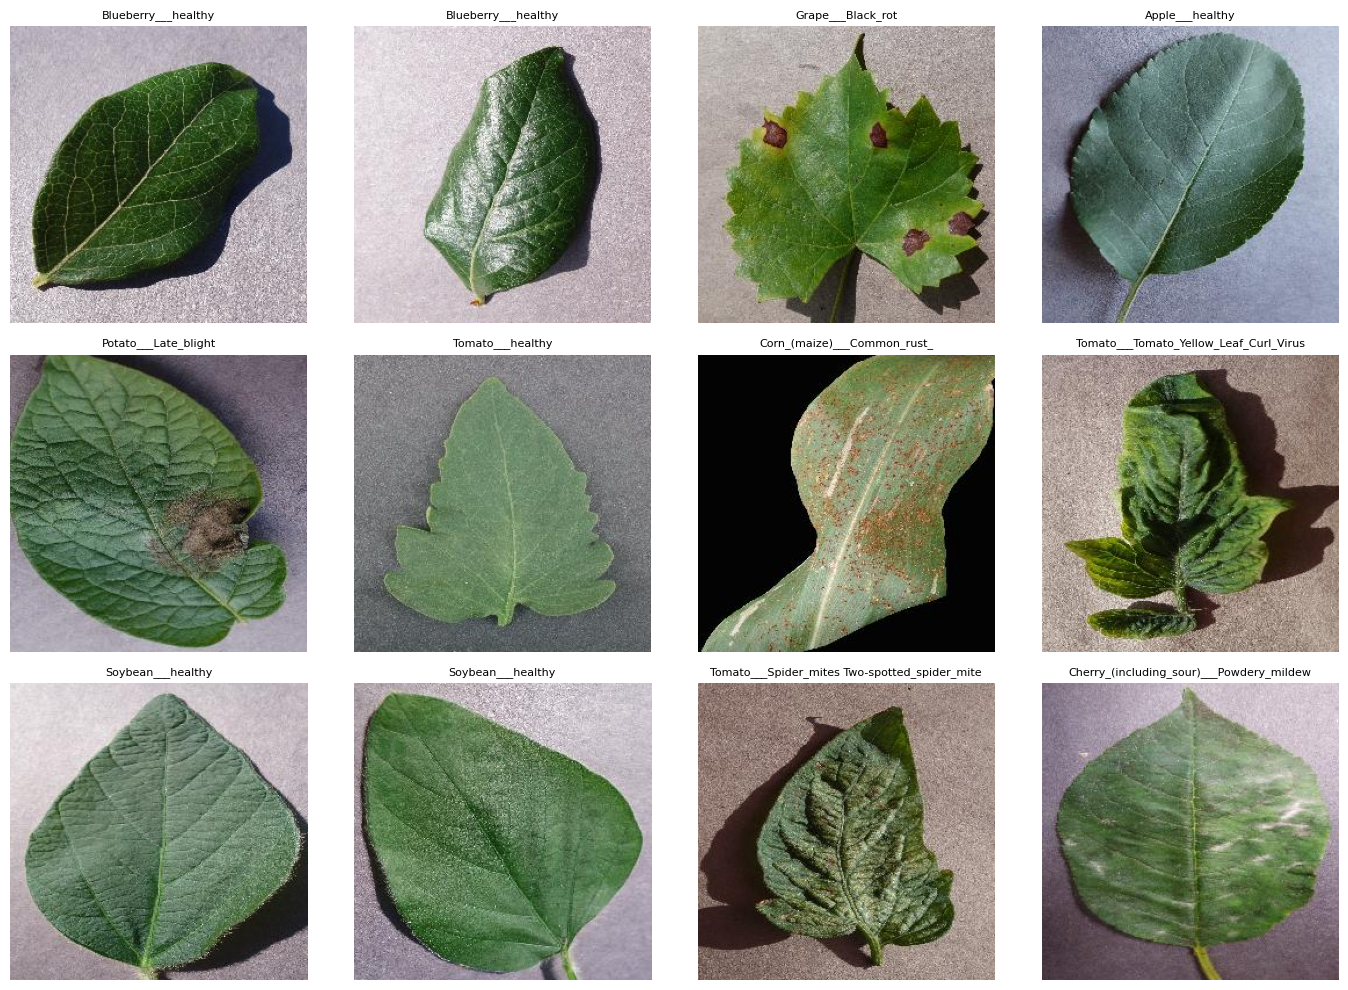

In [10]:
import zipfile, io, random
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)
sample = df[df["split"] == "train"].sample(12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
with zipfile.ZipFile(zip_path) as z:
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = Image.open(io.BytesIO(z.read(row["path"]))).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["class_name"], fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

Smallest class: Potato___healthy 152
Largest class: Orange___Haunglongbing_(Citrus_greening) 5507


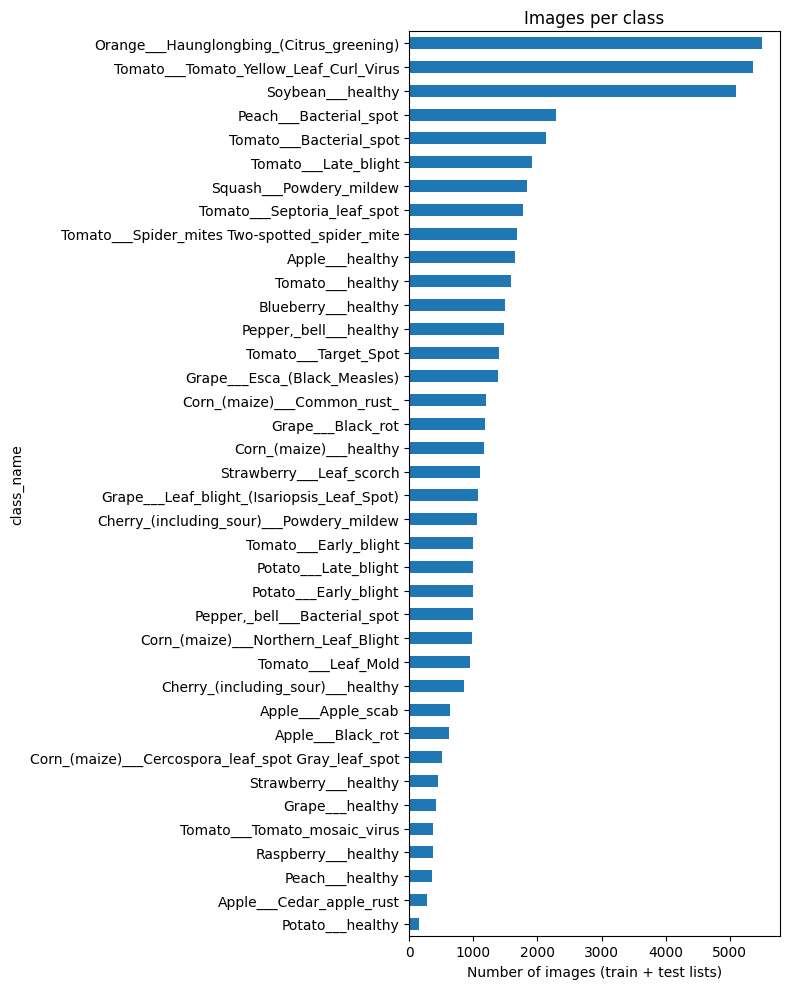

In [11]:
counts = df.groupby("class_name").size().sort_values()
print("Smallest class:", counts.index[0], counts.iloc[0])
print("Largest class:", counts.index[-1], counts.iloc[-1])

plt.figure(figsize=(8, 10))
counts.plot(kind="barh")
plt.xlabel("Number of images (train + test lists)")
plt.title("Images per class")
plt.tight_layout()
plt.show()

In [12]:
counts = df.groupby("class_name").size().sort_values()
small_name, small_n = counts.index[0], int(counts.iloc[0])
large_name, large_n = counts.index[-1], int(counts.iloc[-1])

note = f"""# Dataset metadata: PlantVillage (primary training data)

## Source
- Hugging Face: mohanty/PlantVillage (files used: data.zip, splits/color_train.txt, splits/color_test.txt)
- Original project: https://github.com/spMohanty/PlantVillage-Dataset
- Paper: Mohanty, Hughes and Salathe (2016), "Using deep learning for image-based plant disease detection", Frontiers in Plant Science, 7:1419
- Access date: 10 October 2026

## License
- CC BY-SA 3.0, as stated on the Hugging Face dataset card. To be re-checked against the original source before any redistribution.

## What was loaded
- The `color` configuration named in the roadmap does not exist in the current repo (error: BuilderConfig 'color' not found; only 'default' exists).
- `default` contains only text lists of file paths, not images.
- Images were therefore read from data.zip, using the official color train/test lists.

## Verified counts (my own runs)
- Train list: {len(train_paths):,} images
- Test list: {len(test_paths):,} images
- Total: {len(train_paths) + len(test_paths):,} (the dataset card says 54,306)
- Classes (from folder names): {df['class_name'].nunique()}
- Listed paths missing from the zip: 0
- File paths appearing in both train and test: 0
- Smallest class: {small_name} ({small_n:,} images)
- Largest class: {large_name} ({large_n:,} images)

## Limitations
- Classes are strongly imbalanced, so accuracy alone is misleading; report macro F1 and per-class recall.
- A file-level overlap of 0 does not prove that images of the same physical leaf are kept apart; to be checked in Week 4 using leaf_grouping/leaf-map.json.
- Images come from one collection setting; performance here must not be presented as field reliability (see PlantDoc external evaluation).
- The dataset card and the repo contents disagree (card describes color/grayscale/segmented configs with image and label columns; repo has only text lists).
"""
print(note)

# Dataset metadata: PlantVillage (primary training data)

## Source
- Hugging Face: mohanty/PlantVillage (files used: data.zip, splits/color_train.txt, splits/color_test.txt)
- Original project: https://github.com/spMohanty/PlantVillage-Dataset
- Paper: Mohanty, Hughes and Salathe (2016), "Using deep learning for image-based plant disease detection", Frontiers in Plant Science, 7:1419
- Access date: 10 October 2026

## License
- CC BY-SA 3.0, as stated on the Hugging Face dataset card. To be re-checked against the original source before any redistribution.

## What was loaded
- The `color` configuration named in the roadmap does not exist in the current repo (error: BuilderConfig 'color' not found; only 'default' exists).
- `default` contains only text lists of file paths, not images.
- Images were therefore read from data.zip, using the official color train/test lists.

## Verified counts (my own runs)
- Train list: 43,596 images
- Test list: 10,709 images
- Total: 54,305 (the dataset